In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Total rows loaded: {len(df)}")
df.head()

Saving Electric_Consumption_And_Cost_(2010_-_Sep_2025)_20260327.csv to Electric_Consumption_And_Cost_(2010_-_Sep_2025)_20260327.csv
Total rows loaded: 553666


,Development Name,Borough,Account Name,Location,Meter AMR,Meter Scope,TDS #,EDP,RC Code,Funding Source,...,Meter Number,Estimated,Current Charges,Rate Class,Bill Analyzed,Consumption (KWH),KWH Charges,Consumption (KW),KW Charges,Other charges
0,SHEEPSHEAD BAY,BROOKLYN,SHEEPSHEAD BAY,SHEEPSHEAD BAY BLD 11,AMR,NaN,36.0,314,K003600,FEDERAL,...,12787077,N,"$5,106.45",GOV/NYC/068,Yes,"33,001","$1,523.76",0,$0,"$3,582.69"
1,SHEEPSHEAD BAY,BROOKLYN,SHEEPSHEAD BAY,SHEEPSHEAD BAY BLD 05,AMR,NaN,36.0,314,K003600,FEDERAL,...,12786820,N,"$5,581.02",GOV/NYC/068,Yes,"36,068","$1,665.38",0,$0,"$3,915.64"
2,SHEEPSHEAD BAY,BROOKLYN,SHEEPSHEAD BAY,SHEEPSHEAD BAY BLD 18,AMR,NaN,36.0,314,K003600,FEDERAL,...,4499227,N,"$4,791.96",GOV/NYC/068,Yes,"30,969","$1,429.94",0,$0,"$3,362.02"
3,SHEEPSHEAD BAY,BROOKLYN,SHEEPSHEAD BAY,SHEEPSHEAD BAY BLD 01,AMR,NaN,36.0,314,K003600,FEDERAL,...,12787144,N,"$6,225.81",GOV/NYC/068,Yes,"40,235","$1,857.78",0,$0,"$4,368.03"
4,SHEEPSHEAD BAY,BROOKLYN,SHEEPSHEAD BAY,SHEEPSHEAD BAY BLD 08,AMR,NaN,36.0,314,K003600,FEDERAL,...,12787064,N,"$5,254.21",GOV/NYC/068,Yes,"33,956","$1,567.86",0,$0,"$3,686.35"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553666 entries, 0 to 553665
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Development Name    553035 non-null  object 
 1   Borough             553666 non-null  object 
 2   Account Name        553666 non-null  object 
 3   Location            538111 non-null  object 
 4   Meter AMR           552027 non-null  object 
 5   Meter Scope         29322 non-null   object 
 6   TDS #               551654 non-null  float64
 7   EDP                 553666 non-null  int64  
 8   RC Code             553666 non-null  object 
 9   Funding Source      553666 non-null  object 
 10  AMP #               551193 non-null  object 
 11  Vendor Name         553666 non-null  object 
 12  UMIS BILL ID        553666 non-null  int64  
 13  Revenue Month       553666 non-null  object 
 14  Service Start Date  553618 non-null  object 
 15  Service End Date    553618 non-nul

In [ ]:
df['Revenue Month'].value_counts()

,count
Revenue Month,
2020-04,6781
2020-02,6780
2020-03,6776
2020-01,6770
2025-03,3837
...,...
2010-06,2420
2010-04,2420
2010-03,2413


In [ ]:
# This is so we know the exact case syntax of values in 'Borough' to exclude/include
print(df['Borough'].unique().tolist())

['BROOKLYN', 'MANHATTAN', 'QUEENS', 'BRONX', 'STATEN ISLAND', 'NON DEVELOPMENT FACILITY', 'FHA']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Create the data frame using only the variables we are interested in
df_condense = df[['Borough', 'Revenue Month', 'Consumption (KWH)', 'Current Charges']].copy()

## Data Cleaning
df_condense['Revenue Month'] = pd.to_datetime(df_condense['Revenue Month'])

for col in ['Current Charges', 'Consumption (KWH)']:
    if df_condense[col].dtype == 'object':
        df_condense[col] = df_condense[col].replace('[\$,]', '', regex=True).astype(float)

# Remove FHA and Non Development Facility from Borough (we only want to study the 5 official boroughs of NYC)
excluded = ['FHA', 'NON DEVELOPMENT FACILITY']
df_condense = df_condense[~df_condense['Borough'].str.upper().isin(excluded)]

# Aggregate by Month and Borough
monthly_data = df_condense.groupby(['Revenue Month', 'Borough'])['Consumption (KWH)'].sum().reset_index()

<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_5410/507937140.py:13: SyntaxWarning: invalid escape sequence '\$'
  df_condense[col] = df_condense[col].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
monthly_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Revenue Month      825 non-null    datetime64[ns]
 1   Borough            825 non-null    object        
 2   Consumption (KWH)  825 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 19.5+ KB


## Cleaning

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ensure datetime format
df_condense['Revenue Month'] = pd.to_datetime(df_condense['Revenue Month'])

# 2. Check for Gaps (Temporal Continuity)
# We need to check if each Borough has a complete sequence of months
def check_time_gaps(data, time_col, group_col, freq='MS'):
    report = []
    for group in data[group_col].unique():
        subset = data[data[group_col] == group].sort_values(time_col)

        # Create the 'perfect' range from start to end
        perfect_range = pd.date_range(start=subset[time_col].min(),
                                      end=subset[time_col].max(),
                                      freq=freq)

        # Find which dates in the perfect range are missing in the actual data
        missing_dates = perfect_range.difference(subset[time_col])

        report.append({
            'Borough': group,
            'Start': subset[time_col].min(),
            'End': subset[time_col].max(),
            'Expected_Months': len(perfect_range),
            'Actual_Months': len(subset),
            'Missing_Count': len(missing_dates),
            'Missing_Dates': missing_dates.tolist()
        })
    return pd.DataFrame(report)

gap_report = check_time_gaps(monthly_data, 'Revenue Month', 'Borough')
print(gap_report[['Borough', 'Missing_Count', 'Actual_Months']])

         Borough  Missing_Count  Actual_Months
0          BRONX             24            165
1       BROOKLYN             24            165
2      MANHATTAN             24            165
3         QUEENS             24            165
4  STATEN ISLAND             24            165


In [ ]:
monthly_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Revenue Month      825 non-null    datetime64[ns]
 1   Borough            825 non-null    object        
 2   Consumption (KWH)  825 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 19.5+ KB


In [ ]:
monthly_data['Revenue Month'].value_counts()

,count
Revenue Month,
2010-01-01,5
2010-02-01,5
2010-03-01,5
2010-04-01,5
2010-05-01,5
...,...
2025-05-01,5
2025-06-01,5
2025-07-01,5


In [ ]:
monthly_data.isnull().sum()

,0
Revenue Month,0
Borough,0
Consumption (KWH),0


### Missing gap

In [ ]:
# Assuming 'gap_report' is the dataframe from the previous step
for index, row in gap_report.iterrows():
    print(f"--- Missing Months for {row['Borough']} ---")
    # Print the first 5 and last 5 missing dates to see the range
    missing_list = sorted(row['Missing_Dates'])
    if len(missing_list) > 0:
        print(f"First missing: {missing_list[0]}")
        print(f"Last missing: {missing_list[-1]}")
    print("\n")

--- Missing Months for BRONX ---
First missing: 2011-01-01 00:00:00
Last missing: 2018-12-01 00:00:00


--- Missing Months for BROOKLYN ---
First missing: 2011-01-01 00:00:00
Last missing: 2018-12-01 00:00:00


--- Missing Months for MANHATTAN ---
First missing: 2011-01-01 00:00:00
Last missing: 2018-12-01 00:00:00


--- Missing Months for QUEENS ---
First missing: 2011-01-01 00:00:00
Last missing: 2018-12-01 00:00:00


--- Missing Months for STATEN ISLAND ---
First missing: 2011-01-01 00:00:00
Last missing: 2018-12-01 00:00:00




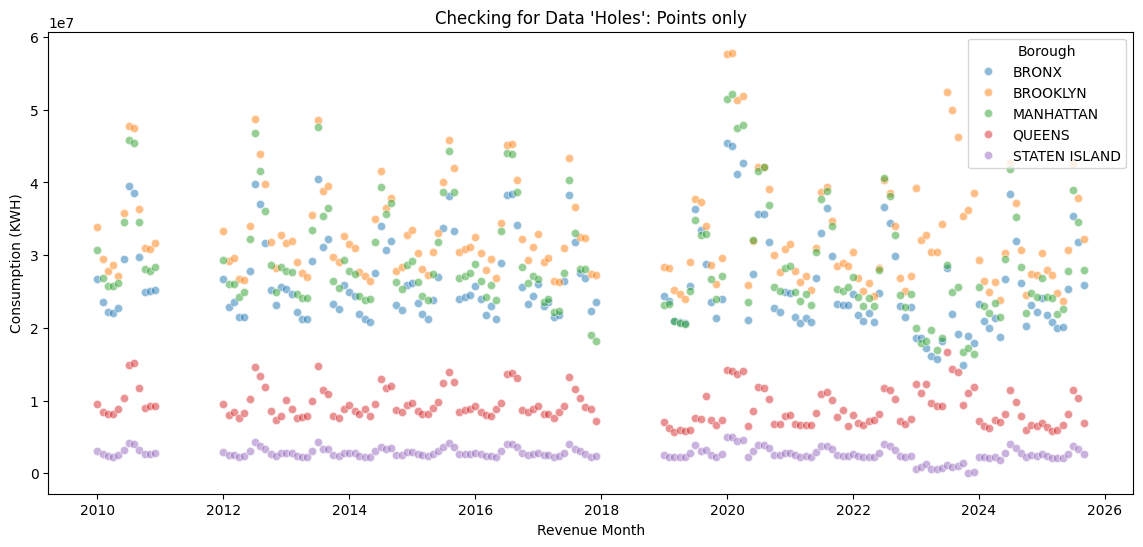

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
# Using markers='o' and linestyle='' (none) shows only where data actually exists
sns.lineplot(data=monthly_data, x='Revenue Month', y='Consumption (KWH)',
             hue='Borough', marker='o', linestyle='', alpha=0.5)

plt.title("Checking for Data 'Holes': Points only")
plt.show()

## EDA (After data selection, need to update)

### Selecting 2019-recent data

Missing values in Modern Era (2019+):
Borough
BRONX            0
BROOKLYN         0
MANHATTAN        0
QUEENS           0
STATEN ISLAND    0
dtype: int64


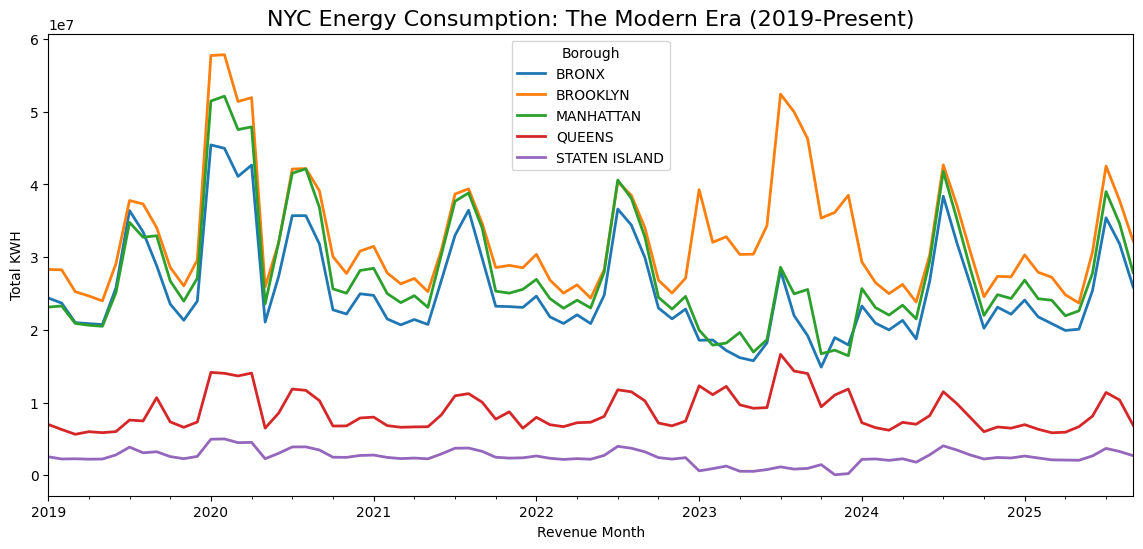

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. Slice the range: Only Jan 2019 onwards
# This ensures we have a clean, continuous block for the SARIMA model
df_modern = monthly_data[monthly_data['Revenue Month'] >= '2019-01-01'].copy()

# 2. Pivot the data to create a "Time Series Ready" structure
# This makes it easy to check for gaps and run statistical tests per borough
ts_modern = df_modern.pivot(index='Revenue Month', columns='Borough', values='Consumption (KWH)')

# 3. Final Verification: Check for any remaining NaNs in this range
print("Missing values in Modern Era (2019+):")
print(ts_modern.isnull().sum())

# 4. Success Visualization
ts_modern.plot(figsize=(14, 6), linewidth=2)
plt.title("NYC Energy Consumption: The Modern Era (2019-Present)", fontsize=16)
plt.ylabel("Total KWH")
plt.show()

### "Is the overall trend rising or falling in the last 5 years?"

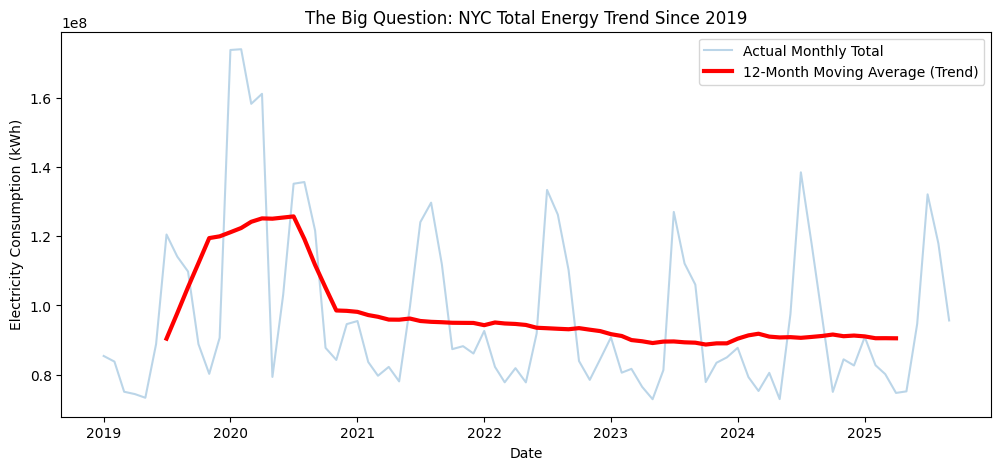

In [ ]:
# Calculate the Rolling Mean (12-month) for the total city
city_total_modern = ts_modern.sum(axis=1)
city_trend = city_total_modern.rolling(window=12, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(city_total_modern, alpha=0.3, label='Actual Monthly Total')
plt.plot(city_trend, color='red', linewidth=3, label='12-Month Moving Average (Trend)')
plt.title("The Big Question: NYC Total Energy Trend Since 2019")
plt.xlabel("Date")
plt.ylabel("Electricity Consumption (kWh)")
plt.legend()
plt.show()

### "Does consumption follow a seasonal cycle (Weather-based) or a random walk?"

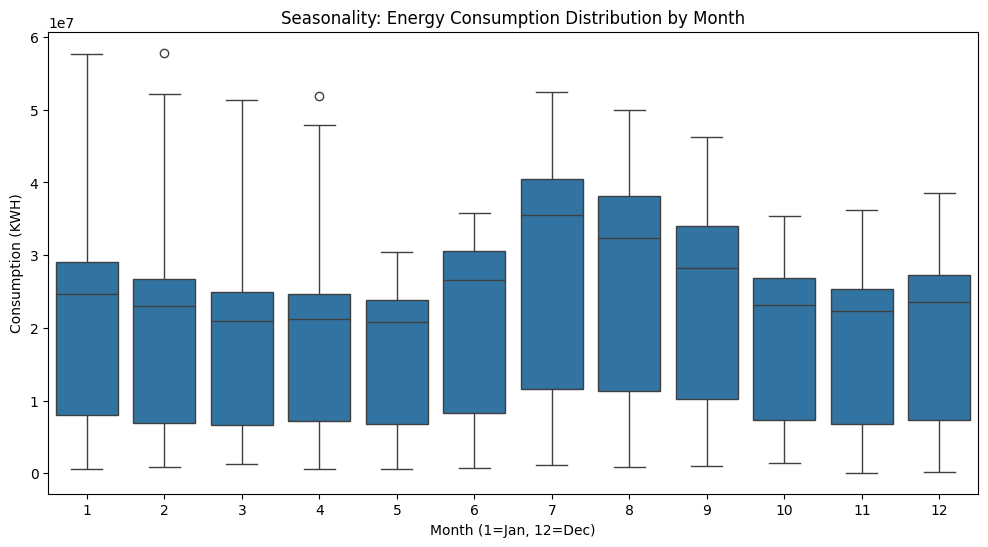

In [ ]:
# Create Month and Year features for grouping
monthly_data['Month'] = monthly_data['Revenue Month'].dt.month
monthly_data['Year'] = monthly_data['Revenue Month'].dt.year

plt.figure(figsize=(12, 6))
sns.boxplot(data=monthly_data, x='Month', y='Consumption (KWH)')
plt.title("Seasonality: Energy Consumption Distribution by Month")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.show()

### "Is the data stationary? Do we need to 'Difference' the data for ARIMA?"

In [ ]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

# Test it for a specific borough (e.g., Brooklyn)
brooklyn_data = monthly_data[monthly_data['Borough'] == 'BROOKLYN']['Consumption (KWH)']
test_stationarity(brooklyn_data)

Results of Dickey-Fuller Test:
Test Statistic                  -4.123101
p-value                          0.000887
#Lags Used                      12.000000
Number of Observations Used    152.000000
Critical Value (1%)             -3.474121
Critical Value (5%)             -2.880750
Critical Value (10%)            -2.577013
dtype: float64


##BY SRISHTI EDA

What are the actual Trend, Seasonal, and Residual components for each borough?


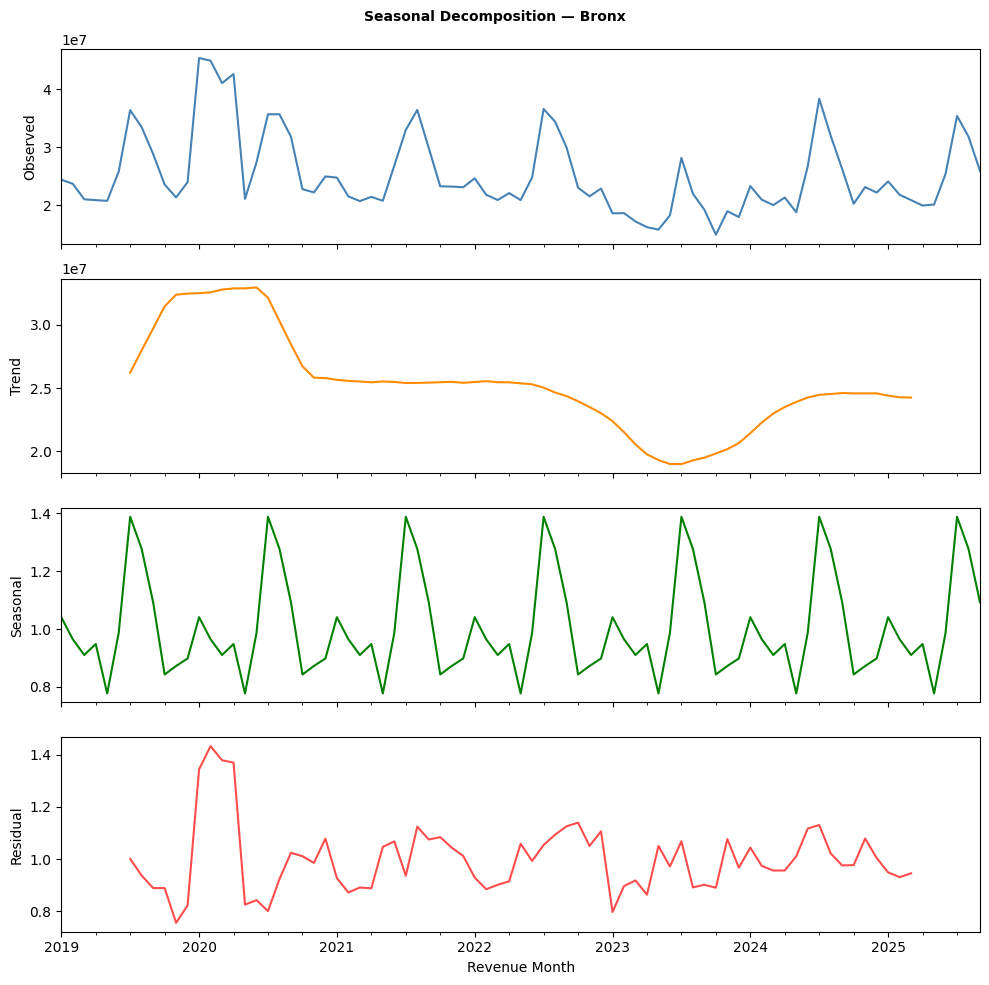

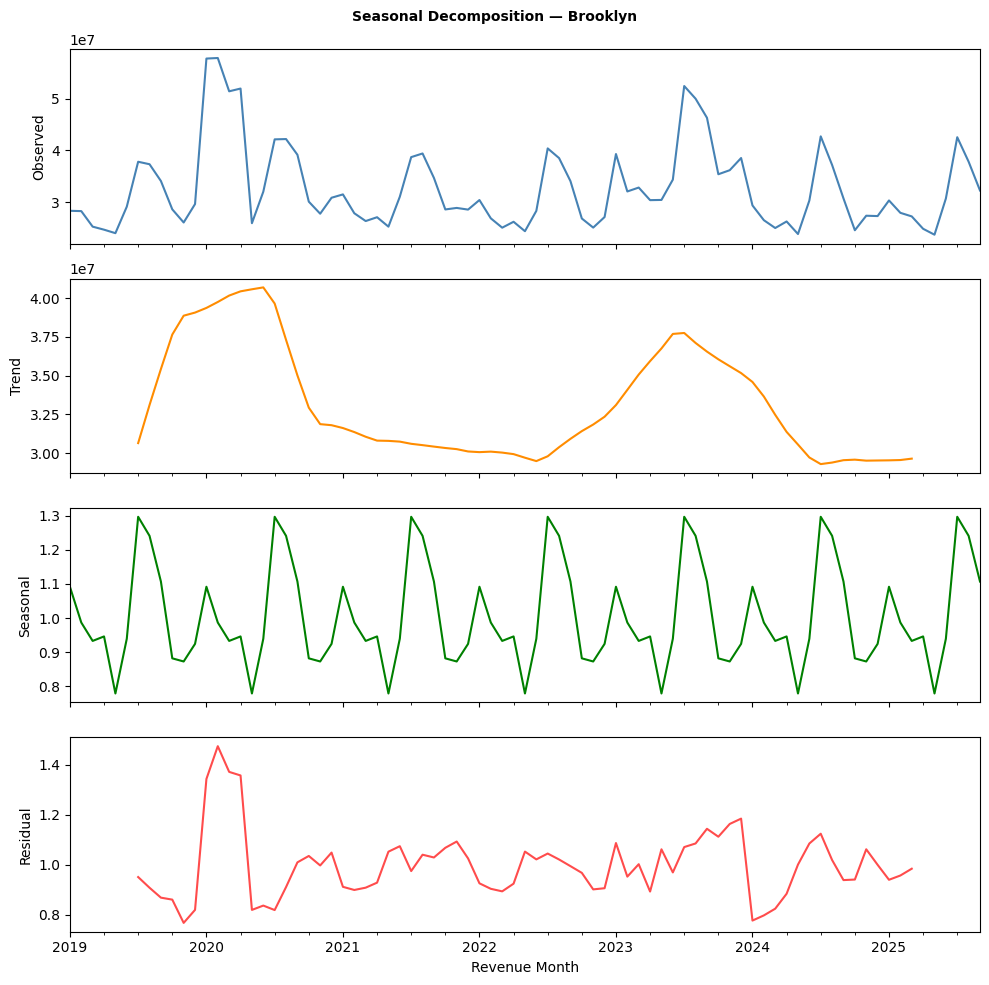

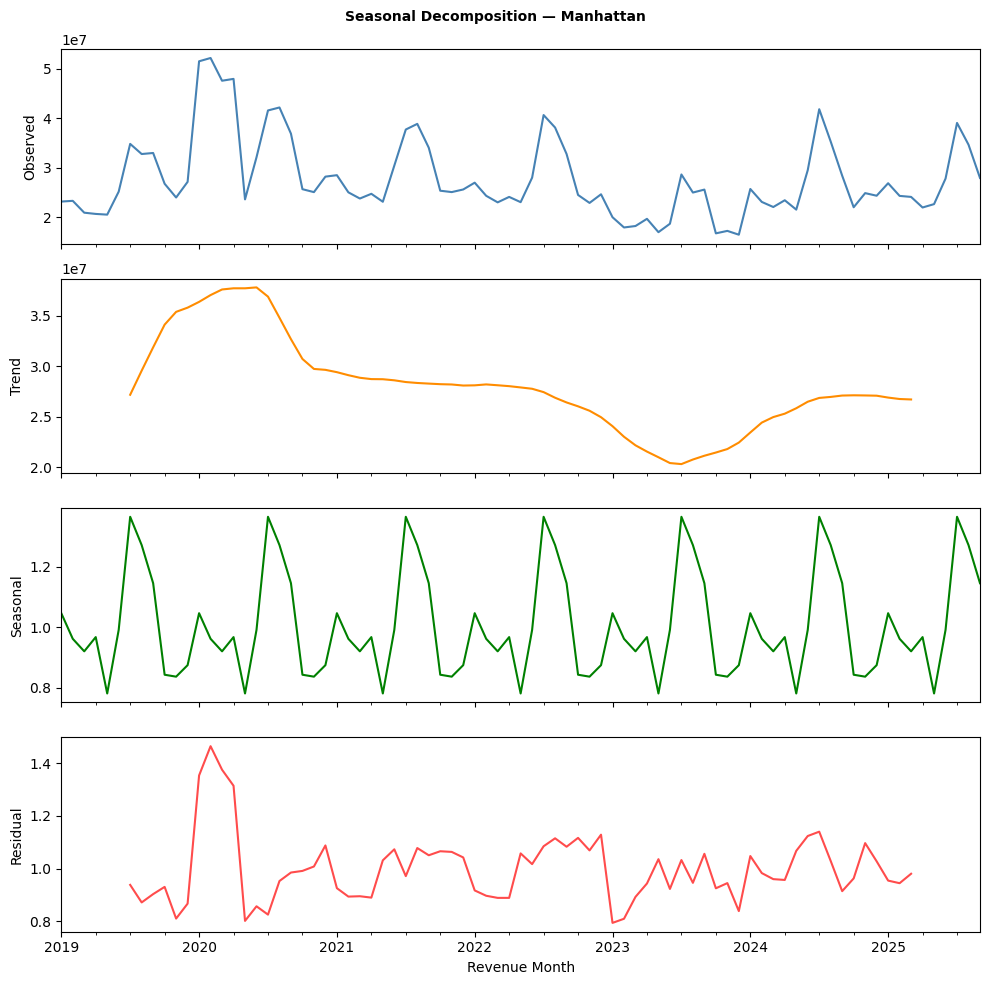

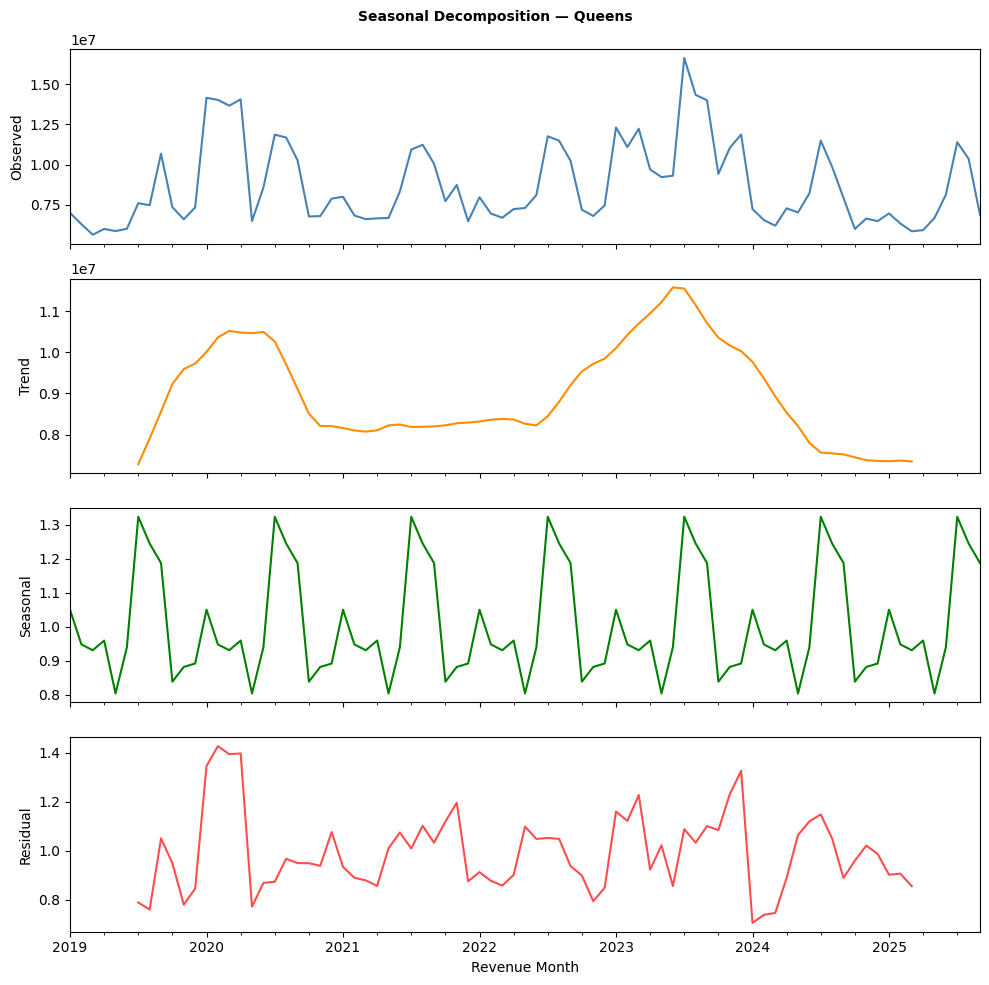

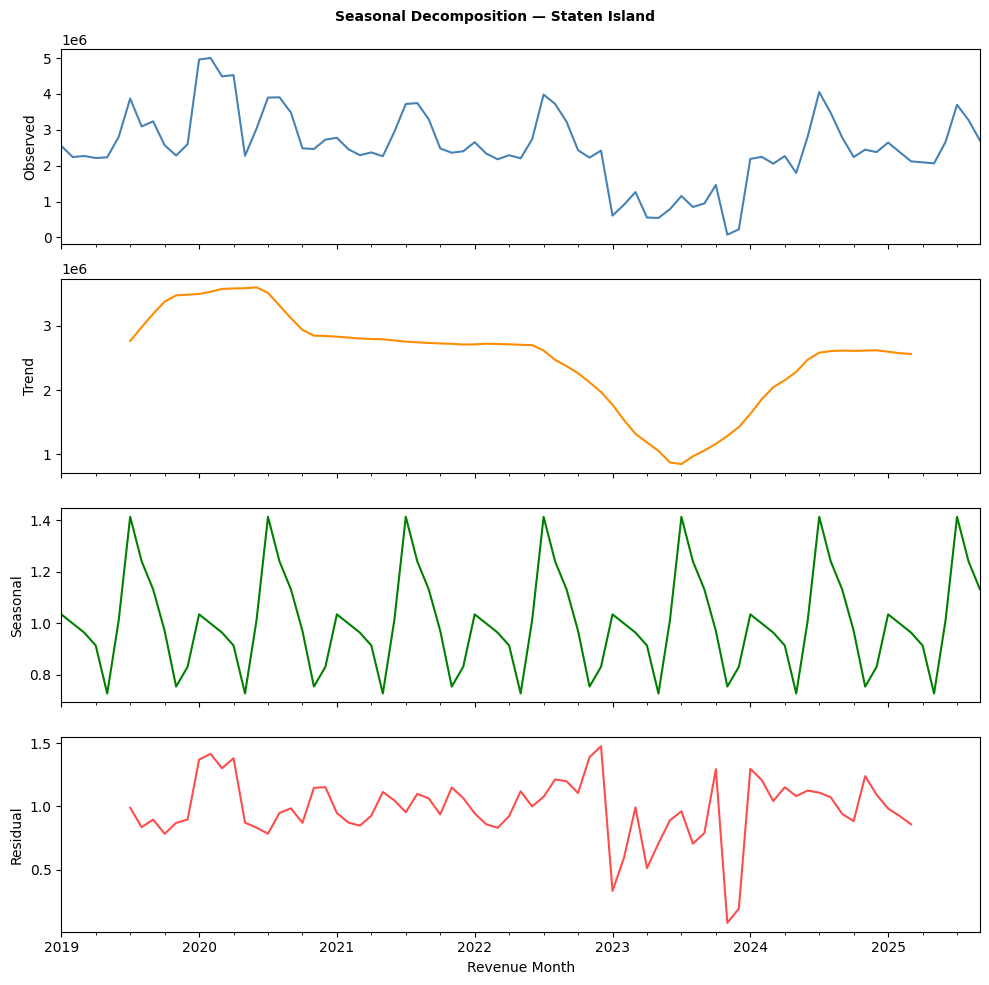

In [ ]:
# @title
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# ts_modern is the pivoted DataFrame (index=Revenue Month, columns=Borough)
boroughs = ts_modern.columns.tolist()

for borough in boroughs:
    series = ts_modern[borough].dropna()

    # Multiplicative decomposition — period=12 for monthly seasonality
    decomposition = seasonal_decompose(series, model='multiplicative', period=12)

    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
    decomposition.observed.plot(ax=axes[0], color='steelblue')
    axes[0].set_ylabel('Observed')

    decomposition.trend.plot(ax=axes[1], color='darkorange')
    axes[1].set_ylabel('Trend')

    decomposition.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Seasonal')

    decomposition.resid.plot(ax=axes[3], color='red', alpha=0.7)
    axes[3].set_ylabel('Residual')

    fig.suptitle(f'Seasonal Decomposition — {borough.title()}', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

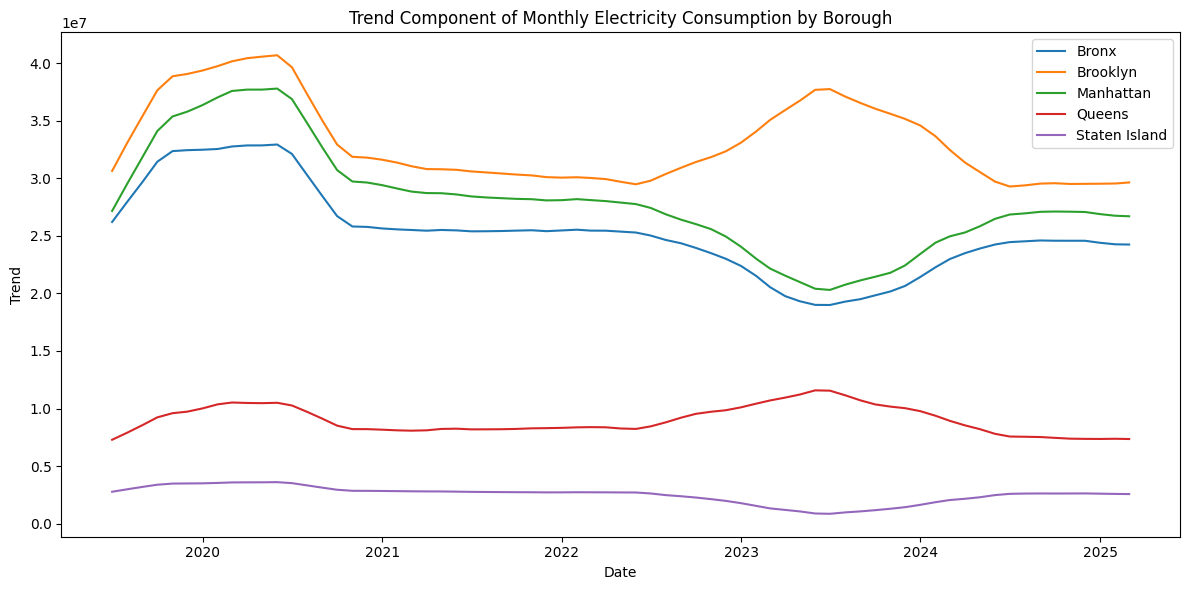

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

boroughs = ts_modern.columns.tolist()

plt.figure(figsize=(12,6))

for borough in boroughs:
    series = ts_modern[borough].dropna()
    decomposition = seasonal_decompose(series, model='multiplicative', period=12)
    plt.plot(decomposition.trend.index, decomposition.trend.values, label=borough.title())

plt.title('Trend Component of Monthly Electricity Consumption by Borough')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.legend()
plt.tight_layout()
plt.show()

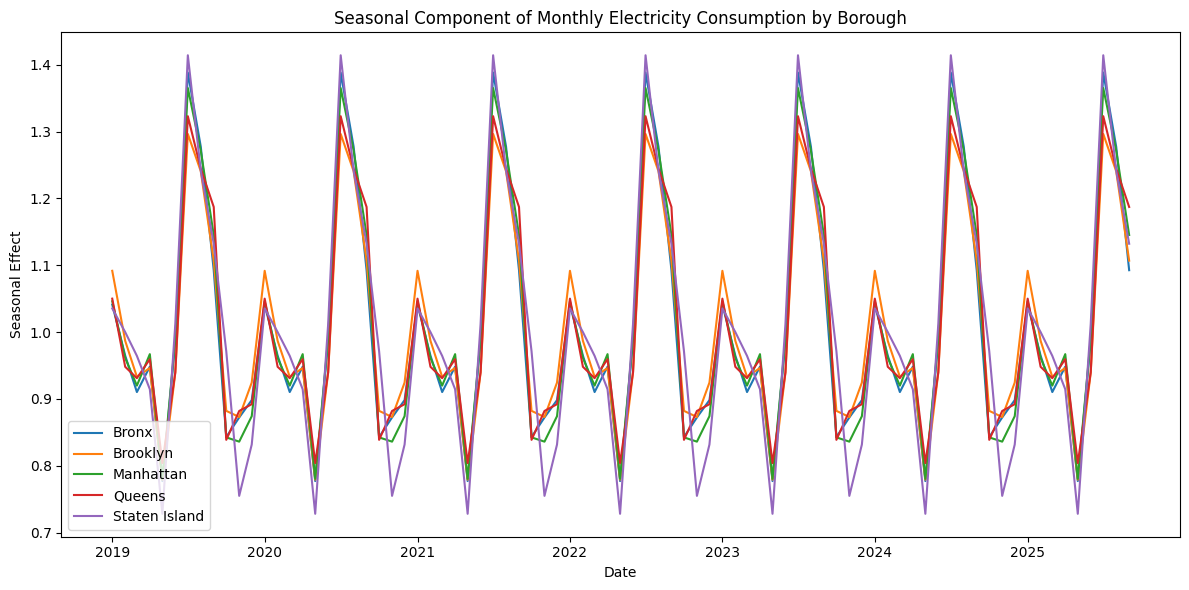

In [ ]:
plt.figure(figsize=(12,6))

for borough in boroughs:
    series = ts_modern[borough].dropna()
    decomposition = seasonal_decompose(series, model='multiplicative', period=12)
    plt.plot(decomposition.seasonal.index, decomposition.seasonal.values, label=borough.title())

plt.title('Seasonal Component of Monthly Electricity Consumption by Borough')
plt.xlabel('Date')
plt.ylabel('Seasonal Effect')
plt.legend()
plt.tight_layout()
plt.show()

---
## ACF & PACF Plots
### "What lag structure should we use for ARIMA? What do p and q look like for each borough?"

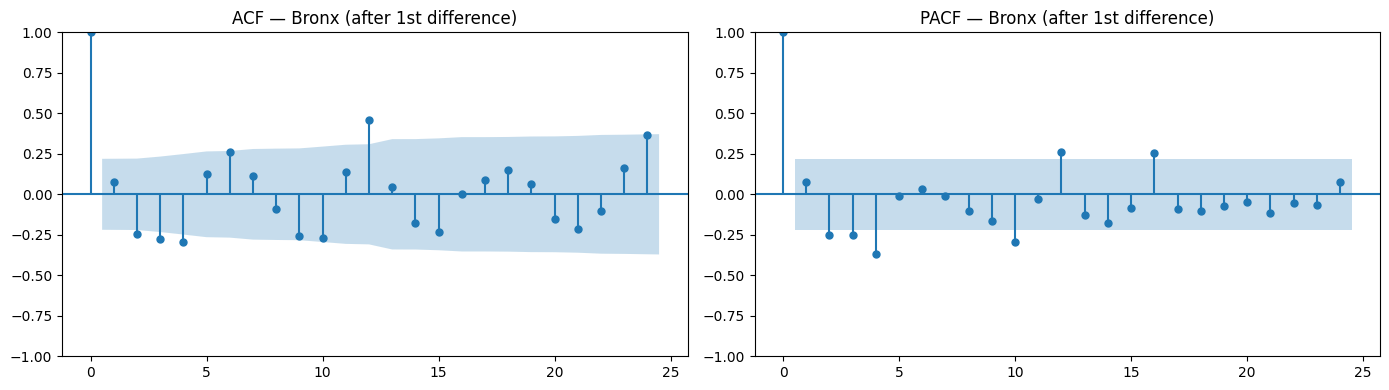

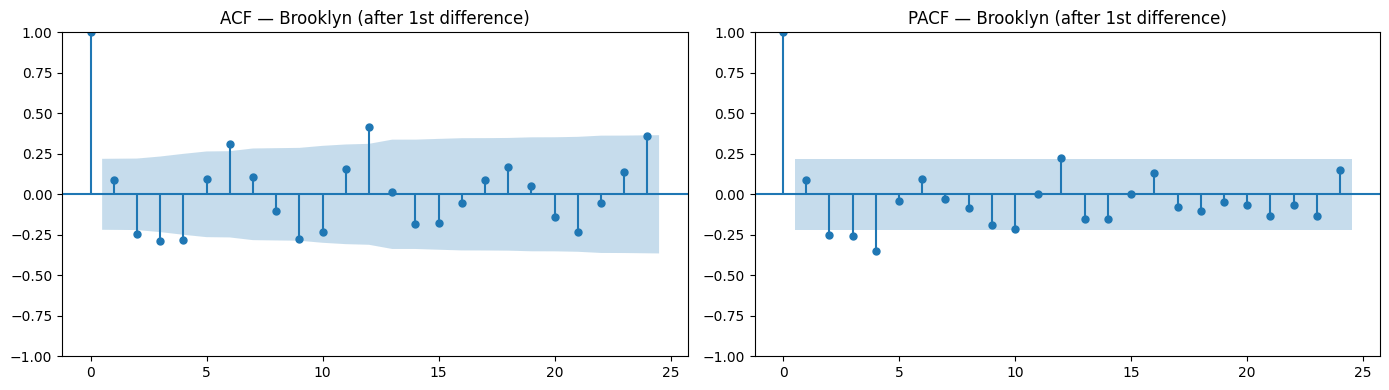

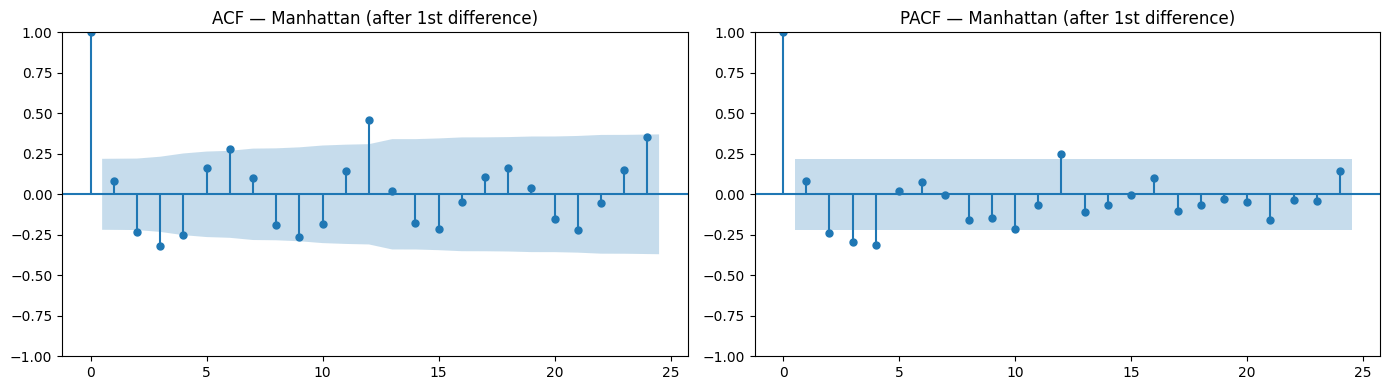

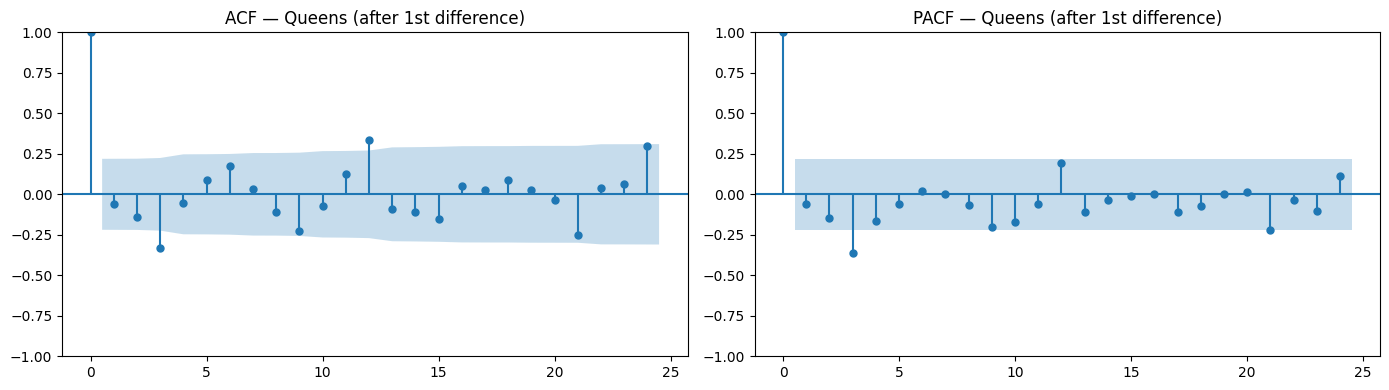

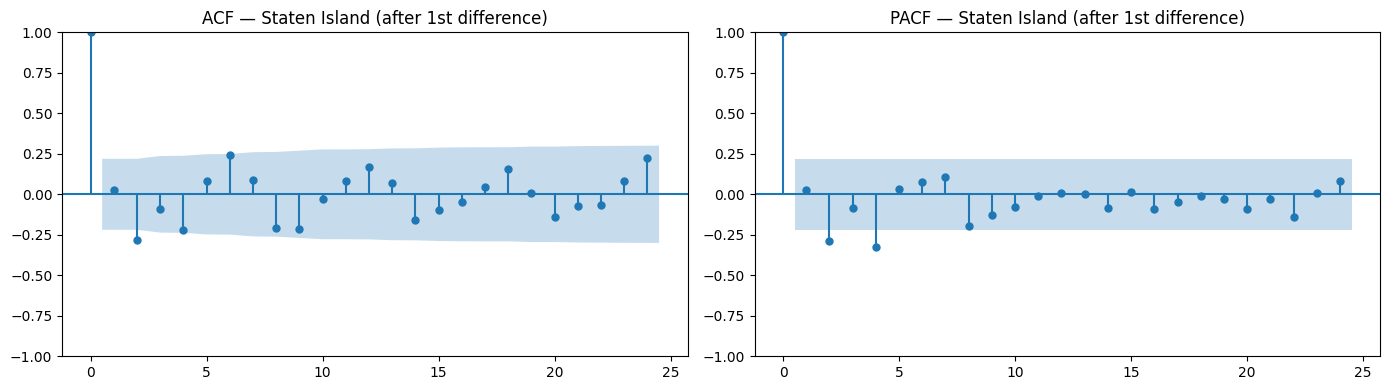

Interpretation:
  PACF cuts off after lag p  ->  use that value for p
  ACF  cuts off after lag q  ->  use that value for q
  d=1 already decided by the ADF test above


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

for borough in boroughs:
    series = ts_modern[borough].dropna()

    # Apply first difference (d=1) — same as what ADF test motivated
    series_diff = series.diff(1).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(series_diff, lags=24, ax=axes[0])
    axes[0].set_title(f'ACF — {borough.title()} (after 1st difference)')

    plot_pacf(series_diff, lags=24, ax=axes[1], method='ywm')
    axes[1].set_title(f'PACF — {borough.title()} (after 1st difference)')

    plt.tight_layout()
    plt.show()

print('Interpretation:')
print('  PACF cuts off after lag p  ->  use that value for p')
print('  ACF  cuts off after lag q  ->  use that value for q')
print('  d=1 already decided by the ADF test above')

In [ ]:
series = ts_modern["brooklyn"].dropna()
series_diff = series.diff(1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_diff, lags=24, ax=axes[0])
axes[0].set_title('ACF — Brooklyn (after 1st difference)')

plot_pacf(series_diff, lags=24, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Brooklyn (after 1st difference)')

plt.tight_layout()
plt.show()

KeyError: 'brooklyn'

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for borough in boroughs:
    series = ts_modern[borough].dropna()
    series_diff = series.diff(1).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series_diff, lags=24, ax=axes[0])
    axes[0].set_title(f'ACF — {borough.title()} (after 1st difference)')
    plot_pacf(series_diff, lags=24, ax=axes[1], method='ywm')
    axes[1].set_title(f'PACF — {borough.title()} (after 1st difference)')
    plt.tight_layout()
    plt.show()

print('Interpretation:')
print('  PACF cuts off after lag p  ->  AR order p')
print('  ACF  cuts off after lag q  ->  MA order q')
print('  d=1 confirmed by ADF test')
print('  -> Significant structure at lags 1-2 across boroughs: use ARIMA(2,1,2)')

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_models = {}

# ARIMA(p=1, d=1, q=1) — order chosen from ACF/PACF above
# p=1: one AR lag, d=1: first difference, q=1: one MA lag
p, d, q = 1, 1, 1

for borough in boroughs:
    series = ts_modern[borough].dropna()

    model = ARIMA(series, order=(p, d, q))
    fit = model.fit()
    arima_models[borough] = fit

    print(f'{borough.title():15s} | AIC: {fit.aic:.2f} | BIC: {fit.bic:.2f}')

# Results (for reference):
# Bronx         AIC: 2713.23
# Brooklyn      AIC: 2743.76
# Manhattan     AIC: 2731.19
# Queens        AIC: 2563.17
# Staten Island AIC: 2378.56

In [ ]:
for borough in boroughs:
    arima_models[borough].plot_diagnostics(figsize=(14, 8))
    plt.suptitle(f'ARIMA(1,1,1) Residual Diagnostics — {borough.title()}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# ==================================================
# Step 4: Simulate non-stationary series for ARIMA
# Random walk with drift: Y_t = Y_{t-1} + epsilon_t
# ARIMA(p,d,q): p=AR order, d=differencing, q=MA order
# ==================================================

y_nonstationary = ts_modern['brooklyn'].dropna().values  # Random walk (d=1)

plt.figure(figsize=(10, 4))
plt.plot(y_nonstationary)
plt.title("Non-Stationary Series (Random Walk)")
plt.xlabel("Time")
plt.ylabel("Y_t")
plt.show()

# Fit ARIMA(1,1,1) model
# - p=1: AR(1) term
# - d=1: first difference to make series stationary
# - q=1: MA(1) term
model = ARIMA(y_nonstationary, order=(1, 1, 1))
fit = model.fit()
print(fit.summary())

# Diagnostics plots
fit.plot_diagnostics(figsize=(10, 6))
plt.show()

## Monthly Forecast — Consumption (2026)

In [ ]:
n_forecast = 15  # Oct 2025 through Dec 2026
palette = sns.color_palette('bright', len(boroughs))

fig, axes = plt.subplots(len(boroughs), 1, figsize=(14, 4 * len(boroughs)), sharex=False)

annual_kwh = {}
for i, borough in enumerate(boroughs):
    ax = axes[i]
    series = ts_modern[borough].dropna()

    forecast_obj  = arima_models[borough].get_forecast(steps=n_forecast)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci   = forecast_obj.conf_int(alpha=0.05)

    # Last 3 years of history for context
    series_recent = series['2022':]
    ax.plot(series_recent, label='Historical', color=palette[i], linewidth=2)
    ax.plot(forecast_mean, label='Forecast', color=palette[i], linestyle='--', linewidth=2)
    ax.fill_between(forecast_ci.index,
                    forecast_ci.iloc[:, 0],
                    forecast_ci.iloc[:, 1],
                    color=palette[i], alpha=0.15, label='95% CI')
    ax.axvline(x=series.index[-1], color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f'{borough.title()} — Consumption Forecast Through 2026', fontsize=12)
    ax.set_ylabel('KWH')
    ax.legend(loc='upper left', fontsize=8)

    forecast_2026 = forecast_mean[forecast_mean.index.year == 2026]
    annual_kwh[borough] = forecast_2026.sum()

plt.suptitle('NYC Borough-Level Electricity Consumption Forecast — ARIMA(2,1,2)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
annual_df = pd.DataFrame.from_dict(annual_kwh, orient='index', columns=['Projected KWH 2026'])
annual_df = annual_df.sort_values('Projected KWH 2026', ascending=False)
annual_df.index = annual_df.index.str.title()
annual_df['M KWH'] = annual_df['Projected KWH 2026'] / 1e6

print(annual_df[['M KWH']].rename(columns={'M KWH': 'Projected 2026 (Million KWH)'}).to_string(
    float_format='{:,.2f}'.format))

# Bar chart
palette_bar = sns.color_palette('bright', len(annual_df))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(annual_df.index, annual_df['M KWH'], color=palette_bar, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}M',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Projected 2026 Annual Electricity Consumption by Borough — ARIMA(2,1,2)', fontsize=13)
ax.set_ylabel('Total KWH (Millions)')
ax.set_xlabel('Borough')
plt.tight_layout()
plt.show()

## BEFORE (From Trang/Kaylee)

In [ ]:
## Estimate trendlines & truncate edges to avoid the Edge Effect
window_size = 12  # 12-month smoothing
monthly_data['Smoothed'] = monthly_data.groupby('Borough')['Consumption (KWH)'].transform(
    lambda x: x.rolling(window=window_size, center=True).mean())

# Truncate NaNs so the plot starts/ends exactly where the trend line begins/ends
monthly_data_trunc = monthly_data.dropna(subset=['Smoothed']).copy()

## Visualization
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

boroughs = sorted(monthly_data_trunc['Borough'].unique())
palette = sns.color_palette("bright", len(boroughs))

for i, borough in enumerate(boroughs):
    subset = monthly_data_trunc[monthly_data_trunc['Borough'] == borough]

    # Plot Observed Trends (Thin background)
    plt.plot(subset['Revenue Month'], subset['Consumption (KWH)'],
             color=palette[i], alpha=0.15, linewidth=1)

    # Plot Smoothed Trends (Bold foreground)
    plt.plot(subset['Revenue Month'], subset['Smoothed'],
             color=palette[i], label=f'{borough.title()} ({window_size}-mo MA)', linewidth=3)

plt.title('NYC Monthly Energy Consumption: Trend Estimation (Truncated Edges)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Consumption (KWH)', fontsize=12)
plt.legend(title="Boroughs (Smoothed Trend)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Create the condensed DataFrame using the requested variables
df_condense = df[['Borough', 'Revenue Month', 'Consumption (KWH)', 'Current Charges']].copy()

## Data Cleaning
df_condense['Revenue Month'] = pd.to_datetime(df_condense['Revenue Month'])

for col in ['Current Charges', 'Consumption (KWH)']:
    if df_condense[col].dtype == 'object':
        df_condense[col] = df_condense[col].replace('[\$,]', '', regex=True).astype(float)

# Remove FHA and Non Development Facility from Borough
excluded = ['FHA', 'NON DEVELOPMENT FACILITY']
df_condense = df_condense[~df_condense['Borough'].str.strip().str.upper().isin(excluded)]

## Aggregate by Month and Borough - targeting 'Current Charges'
monthly_data = df_condense.groupby(['Revenue Month', 'Borough'])['Current Charges'].sum().reset_index()

## Estimate trendlines & truncate edges to avoid the Boundary Effect
window_size = 12  # 12-month smoothing to remove seasonal price/usage volatility
monthly_data['Smoothed'] = monthly_data.groupby('Borough')['Current Charges'].transform(
    lambda x: x.rolling(window=window_size, center=True).mean())

# Truncate NaNs so the plot starts/ends exactly where the trend line begins/ends
monthly_data_trunc = monthly_data.dropna(subset=['Smoothed']).copy()

## Visualization
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

boroughs = sorted(monthly_data_trunc['Borough'].unique())
palette = sns.color_palette("bright", len(boroughs))

for i, borough in enumerate(boroughs):
    subset = monthly_data_trunc[monthly_data_trunc['Borough'] == borough]

    # Plot Observed Trends (Thin background - actual monthly bill totals)
    plt.plot(subset['Revenue Month'], subset['Current Charges'],
             color=palette[i], alpha=0.15, linewidth=1)

    # Plot Smoothed Trends (Bold foreground - the 12-month average trend)
    plt.plot(subset['Revenue Month'], subset['Smoothed'],
             color=palette[i], label=f'{borough.title()} ({window_size}-mo MA)', linewidth=3)

# Formatting the chart for Revenue/Cost
plt.title('NYC Monthly Energy Expenditure: Revenue Charge Trends by Borough (2010 - 2025)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Current Charges ($)', fontsize=12)
plt.legend(title="Boroughs (Smoothed Cost Trend)", bbox_to_anchor=(1.05, 1), loc='upper left')

# Format Y-axis with commas for readability
from matplotlib.ticker import StrMethodFormatter
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [ ]:
n_forecast = 15  # Oct 2025 through Dec 2026
palette = sns.color_palette('bright', len(boroughs))

plt.figure(figsize=(16,8))

annual_kwh = {}
for i, borough in enumerate(boroughs):
    series = ts_modern[borough].dropna()

    forecast_obj  = arima_models[borough].get_forecast(steps=n_forecast)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci   = forecast_obj.conf_int(alpha=0.05)

    # Last 3 years of history for context
    series_recent = series['2022':]
    plt.plot(series_recent, label=f'{borough.title()} Historical', color=palette[i], linewidth=2)
    plt.plot(forecast_mean, label=f'{borough.title()} Forecast', color=palette[i], linestyle='--', linewidth=2)

    # optional confidence interval
    plt.fill_between(forecast_ci.index,
                     forecast_ci.iloc[:, 0],
                     forecast_ci.iloc[:, 1],
                     color=palette[i], alpha=0.10)

    forecast_2026 = forecast_mean[forecast_mean.index.year == 2026]
    annual_kwh[borough] = forecast_2026.sum()

plt.axvline(x=series.index[-1], color='gray', linestyle=':', linewidth=1.5)
plt.title('NYC Borough-Level Electricity Consumption Forecast Through 2026', fontsize=15)
plt.xlabel('Date')
plt.ylabel('KWH')
plt.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
n_forecast = 15  # Oct 2025 through Dec 2026
palette = sns.color_palette('bright', len(boroughs))

plt.figure(figsize=(16,8))

annual_kwh = {}
for i, borough in enumerate(boroughs):
    series = ts_modern[borough].dropna()

    forecast_obj  = arima_models[borough].get_forecast(steps=n_forecast)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci   = forecast_obj.conf_int(alpha=0.20)  # 80% confidence interval

    # Last 3 years of history for context
    series_recent = series['2022':]
    plt.plot(series_recent, label=f'{borough.title()} Historical', color=palette[i], linewidth=2)
    plt.plot(forecast_mean, label=f'{borough.title()} Forecast', color=palette[i], linestyle='--', linewidth=2)

    plt.fill_between(forecast_ci.index,
                     forecast_ci.iloc[:, 0],
                     forecast_ci.iloc[:, 1],
                     color=palette[i], alpha=0.06)

    forecast_2026 = forecast_mean[forecast_mean.index.year == 2026]
    annual_kwh[borough] = forecast_2026.sum()

plt.axvline(x=series.index[-1], color='gray', linestyle=':', linewidth=1.5)
plt.title('NYC Borough-Level Electricity Consumption Forecast Through 2026', fontsize=15)
plt.xlabel('Date')
plt.ylabel('KWH')

from matplotlib.patches import Patch
ci_patch = Patch(facecolor='gray', alpha=0.15, label='Shaded area = 80% CI')

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(ci_patch)
labels.append('Shaded area = 80% CI')

plt.legend(handles, labels, loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()